# Initial pilot where we made a small library of 120 sequences with 3 different library contexts

In [ ]:
library(tidyverse)
library(data.table)
library(RColorBrewer)

dir <- "/mnt/thechenlab/Dawn/splicing/library_sequencing_V2/RNA_V2_results_Mounica/"
bc_lib_table_dir <- "/mnt/thechenlab/Dawn/splicing/library_sequencing_V2/DNA_V2_V3_out/"
figure_outdir <- "/mnt/dawnccle2/melange/figures_outputs/figS01"
# Create the output directory if it doesn't exist.
if (!dir.exists(figure_outdir)) {
  dir.create(figure_outdir, recursive = TRUE)
}


count_filenames <- list.files(dir, pattern = "splicing_counter.csv")
bc_table_filenames <- list.files(bc_lib_table_dir, pattern = "lib_table.csv")

###### First we read in the splice count files and do some analysis.
count_file_all <- fread(file.path(dir, count_filenames[1]))
names(count_file_all) <- c("barcode", "unspliced", "included", "skipped")
count_file_all <- count_file_all %>% mutate(filename = count_filenames[1])
for (i in 2:length(count_filenames)){
  tmp <- fread(file.path(dir, count_filenames[i]))
  names(tmp) <- c("barcode", "unspliced", "included", "skipped")
  tmp <- tmp %>% mutate(filename = count_filenames[i])
  count_file_all <- rbind(count_file_all, tmp)
}

# Also read in the old HEK cells
dir2 <- "/mnt/thechenlab/Dawn/splicing/library_sequencing_V2/RNA_V2_results/"

count_filenames <- list.files(dir2, pattern = "splicing_counter.csv")
bc_table_filenames <- list.files(bc_lib_table_dir, pattern = "lib_table.csv")

###### First we read in the splice count files and do some analysis.
count_file_all_r1 <- fread(file.path(dir2, count_filenames[1]))
names(count_file_all_r1) <- c("barcode", "unspliced", "included", "skipped")
count_file_all_r1 <- count_file_all_r1 %>% mutate(filename = count_filenames[1])
for (i in 2:length(count_filenames)){
  tmp <- fread(file.path(dir2, count_filenames[i]))
  names(tmp) <- c("barcode", "unspliced", "included", "skipped")
  tmp <- tmp %>% mutate(filename = count_filenames[i])
  count_file_all_r1 <- rbind(count_file_all_r1, tmp)
}
count_file_all <- rbind(count_file_all, count_file_all_r1)

#### Add some annotations
count_file_all <- count_file_all %>% 
  mutate(celltype = str_extract(filename, "^[^-]+")) %>% 
  # The unannotated ones are HEK cells. 
  mutate(celltype = ifelse(celltype %in% c("293", "K562", "HEK", "A375"), celltype, "293")) %>%
  mutate(libraryID = str_extract(filename, "DC\\d+")) %>%
  filter((libraryID %in% c("DC297", "DC298", "DC299"))) %>% 
  mutate(rep = paste0("rep",str_extract(filename, "(?<=DC29\\d-)\\d+"))) %>%
  mutate(rep = ifelse(rep == "repNA", paste0("rep",str_extract(filename, "(?<=DC2\\d\\d-RNA-)\\d+")), rep)) %>%
  mutate(isLowCycle =grepl("lowCycle", filename)) %>% 
  mutate(sample_full_name = str_extract(filename, "^[:graph:]+(?=_S\\d+_splicing_counter.csv)")) 
  

###### Then we also read in the barcodes for each sample. 
bc_table_all <- fread(file.path(bc_lib_table_dir, bc_table_filenames[1])) 
for (i in 2:length(bc_table_filenames)){
  tmp <- fread(file.path(bc_lib_table_dir, bc_table_filenames[i]))
  bc_table_all <- rbind(bc_table_all, tmp)
}
# Plot how many barcodes are there per library.
bc_count_total <- bc_table_all %>% group_by(libraryID) %>% summarise(total_bc_DNA = n())
ggplot(bc_count_total, aes(libraryID, total_bc_DNA)) + geom_bar(stat = "identity",fill = "lightblue") + 
  theme_classic() + ggtitle("Number of barcodes per library (based on DNA matching)")
# ggsave(file.path(figure_outdir, "0_num_barcodes_per_library.png"), width = 1200, height = 800, units = "px", dpi = 150)

###### Now merge barcodes with the elements
count_bc_merged <- merge(count_file_all, bc_table_all, by = c("libraryID","barcode"))

# Group samples from different runs, basically.
count_bc_merged <- count_bc_merged %>% group_by(sample_full_name, libraryID, barcode, celltype, isLowCycle, rep, id) %>% 
  summarise(unspliced = sum(unspliced), included = sum(included), skipped = sum(skipped))
with_stats <- count_bc_merged %>% 
  mutate(sum_reads = unspliced + included + skipped) %>%
  mutate(PSI = included/(included + skipped)) %>% 
  mutate(percUnspliced = unspliced/(unspliced + included + skipped)) %>%
  filter(sum_reads > 30) %>%
  arrange(desc(sum_reads))

#########LOOK AT SOME SUMMARY STATS
# Read in the summary stats
count_filenames <- list.files(dir, pattern = "stats_log.txt")
stat_file_all <- fread(file.path(dir, count_filenames[1]), header = F)
names(stat_file_all) <- c("metric", "value")
stat_file_all <- stat_file_all %>% mutate(filename = count_filenames[1])
for (i in 2:length(count_filenames)){
  tmp <- fread(file.path(dir, count_filenames[i]))
  names(tmp) <- c("metric", "value")
  tmp <- tmp %>% mutate(filename = count_filenames[i])
  stat_file_all <- rbind(stat_file_all, tmp)
}

stat_file_all <- stat_file_all %>% 
  mutate(celltype = str_extract(filename, "^[^-]+")) %>% 
  # The unannotated ones are HEK cells. 
  mutate(celltype = ifelse(celltype %in% c("293", "K562"), celltype, "293")) %>%
  mutate(libraryID = str_extract(filename, "DC\\d+")) %>%
  mutate(rep = paste0("rep",str_extract(filename, "(?<=DC29\\d-)\\d+"))) %>%
  mutate(isLowCycle =grepl("lowCycle", filename)) %>% 
  mutate(sample_full_name = str_extract(filename, "^[:graph:]+(?=_S\\d+_stats_log.txt)")) %>%
  select(-filename)

# Look at how many of them have barcode not found.
ggplot(stat_file_all %>% filter(metric == "perc_bc_not_found"), aes(libraryID, value*100, fill=celltype)) +  
  geom_bar(alpha = 0.4, stat = "identity", position = "dodge") + 
  theme_classic() + ggtitle("Fraction barcode not found (RNA)") + ylab("% unmatched barcode")
# ggsave(file.path(figure_outdir, "0_percentage_barcode_not_found_RNA.png"), width = 1200, height = 800, units = "px", dpi = 150)

# Total number of reads per pool.
reads_per_pool <- with_stats %>% group_by(libraryID, celltype) %>% summarise(total_reads = sum(sum_reads), reads_per_barcode = sum(sum_reads)/length(unique(barcode)))
ggplot(reads_per_pool, aes(libraryID, log10(total_reads), fill=celltype)) +  geom_bar(alpha = 0.5, stat = "identity", position = "dodge") + 
  theme_classic() + ggtitle("Number of reads per sample")
# ggsave(file.path(figure_outdir, "0_num_reads_per_library.png"), width = 1200, height = 800, units = "px", dpi = 150)

ggplot(reads_per_pool, aes(libraryID, log10(reads_per_barcode), fill=celltype)) +  geom_bar(alpha = 0.5, stat = "identity", position = "dodge") + 
  theme_classic() + ggtitle("Average reads per barcode")
# ggsave(file.path(figure_outdir, "0_num_reads_per_barcode.png"), width = 1200, height = 800, units = "px", dpi = 150)

# Look at number of barcodes detected based on RNA.
bc_count_DNA <- bc_table_all %>% group_by(libraryID) %>% summarise(total_bc_DNA = n())
bc_count_RNA <- with_stats %>% group_by(libraryID) %>% summarise(total_bc_RNA = length(unique(barcode)))
bc_count_total <- merge(bc_count_DNA, bc_count_RNA, by = "libraryID") %>% pivot_longer(cols = starts_with("total_bc"), values_to="total_bc")

ggplot(bc_count_total, aes(libraryID, total_bc, fill = name)) + geom_bar(alpha = 0.5, stat = "identity", position = "dodge") + 
  theme_classic() + ggtitle("Number of barcodes per library (based on DNA matching)")
# ggsave(file.path(figure_outdir, "0_num_barcodes_per_library.png"), width = 1200, height = 800, units = "px", dpi = 150)

# Look at how many barcode elements represented per library. 
elements_per_lib <- with_stats %>% group_by(libraryID) %>% summarise(library_size = length(unique(id)))
ggplot(elements_per_lib, aes(libraryID, library_size)) + geom_bar(alpha = 0.5, stat = "identity", position = "dodge", fill="darkblue") + 
  theme_classic() + ggtitle("Number of elements per library(120 ordered)")
# ggsave(file.path(figure_outdir, "0_num_elements_per_library.png"), width = 1200, height = 800, units = "px", dpi = 150)

# (0) Look at number of reads distribution
ggplot(with_stats, aes(log10(sum_reads),fill = libraryID)) + geom_histogram(bins = 100) +
  facet_wrap(~libraryID + celltype + rep) + theme_classic() + ggtitle("Reads distribution for library elements")
# ggsave(file.path(figure_outdir, "0_reads_distribution_per_element.png"), width = 2400, height = 1600, units = "px", dpi = 150)


# (1) compare between replicates. 
# We will need to filter by spliced reads > 30, not just by total reads. Some elements are not spliced.
compare_by_reps <- with_stats %>% 
  dplyr::filter(included+skipped>30) %>%
  ungroup()  %>% 
  select(libraryID, barcode, celltype, isLowCycle, rep, PSI) %>% 
  pivot_wider(names_from = rep, values_from = PSI)
ggplot(compare_by_reps, aes(rep1, rep2, color = libraryID)) + geom_point(alpha = 0.5) + 
  facet_wrap(~libraryID + celltype) + theme_classic() + ggtitle("PSI correlation between sample replicates")
# ggsave(file.path(figure_outdir, "1_corr_between_sample_reps.png"), width = 2400, height = 2000, units = "px", dpi = 150)

# Compare between replicates that also include the unspliced reads. 
compare_by_reps <- with_stats %>% 
  ungroup()  %>% 
  select(libraryID, barcode, celltype, isLowCycle, rep, PSI) %>% 
  pivot_wider(names_from = rep, values_from = PSI)
ggplot(compare_by_reps, aes(rep1, rep2, color = libraryID)) + geom_point(alpha = 0.5) + 
  facet_wrap(~libraryID + celltype) + theme_classic() + ggtitle("PSI correlation between sample replicates (including unspliced reads)")
# ggsave(file.path(figure_outdir, "1_corr_between_sample_reps_with_unspliced.png"), width = 2400, height = 1600, units = "px", dpi = 150)

# Compare between replicates the percentage of reads that are unspliced.
compare_by_reps <- with_stats %>% 
  ungroup()  %>% 
  select(libraryID, barcode, celltype, isLowCycle, rep, percUnspliced) %>% 
  pivot_wider(names_from = rep, values_from = percUnspliced)
ggplot(compare_by_reps, aes(rep1, rep2, color = libraryID)) + geom_point(alpha = 0.5) + 
  facet_wrap(~libraryID + celltype) + theme_classic() + ggtitle("Percentage reads unspliced correlation between sample replicates ")
# ggsave(file.path(figure_outdir, "1_corr_between_sample_reps_percentage_unspliced.png"), width = 2400, height = 1600, units = "px", dpi = 150)

# Also plot in histogram form.
ggplot(with_stats, aes(percUnspliced)) + geom_histogram(bins = 25, fill = "brown") + theme_classic() + 
  facet_grid(libraryID ~ celltype, scales = "free_y") + 
  ggtitle("Histogram of Perc Unspliced")

# (2) compare between cell types. 
# We will need to filter by spliced reads > 30, not just by total reads. Some elements are not spliced.
with_stats_merged_runs <- count_bc_merged %>% 
  filter((libraryID %in% c("DC297", "DC298", "DC299"))) %>%
  group_by(libraryID, barcode, celltype, id) %>%
  summarise(unspliced = sum(unspliced), included = sum(included), skipped = sum(skipped))%>%
  mutate(total_reads = unspliced + included + skipped) %>% 
  mutate(percUnspliced = unspliced/total_reads) %>% 
  mutate(PSI = included/(included+skipped)) 

compare_by_celltypes <- with_stats_merged_runs %>% ungroup()%>%  
  filter(total_reads < 2500 & total_reads > 20) %>% 
  filter(included + skipped > 30) %>%
  select(libraryID, barcode, celltype, id, PSI) %>% 
  pivot_wider(names_from = celltype, values_from = PSI)

# write.csv(compare_by_celltypes, file.path(figure_outdir, "compare_by_celltypes_all_barcodes.csv"))

ggplot(compare_by_celltypes, aes(`293`, K562)) + geom_point(alpha = 0.5) + 
  facet_wrap(~libraryID) + theme_classic() + ggtitle("PSI between cell type (all barcodes)")
# ggsave(file.path(figure_outdir, "2_PSI_between_celltype_by_barcode_HEK_K562.png"), width = 1200, height = 600, units = "px", dpi = 150)


# Compare between HEK r1 and HEK r2
ggplot(compare_by_celltypes, aes(`293`, HEK)) + geom_point(alpha = 0.5) + 
  facet_wrap(~libraryID) + theme_classic() + ggtitle("PSI between cell type (all barcodes)") +
  xlab("Mounica HEK293") + ylab("Dawn HEK293")
# ggsave(file.path(figure_outdir, "2_PSI_between_celltype_by_barcode_HEK_R1_R2.png"), width = 1200, height = 600, units = "px", dpi = 150)

# K562 and A375
ggplot(compare_by_celltypes, aes(A375, K562)) + geom_point(alpha = 0.5) + 
  facet_wrap(~libraryID) + theme_classic() + ggtitle("PSI between cell type (all barcodes)") 
# ggsave(file.path(figure_outdir, "2_PSI_between_celltype_by_barcode_K562_A375.png"), width = 1200, height = 600, units = "px", dpi = 150)

# HEK A375
ggplot(compare_by_celltypes, aes(HEK, A375)) + geom_point(alpha = 0.5) + 
  facet_wrap(~libraryID) + theme_classic() + ggtitle("PSI between cell type (all barcodes)") 
# ggsave(file.path(figure_outdir, "2_PSI_between_celltype_by_barcode_HEK_A375.png"), width = 1200, height = 600, units = "px", dpi = 150)


with_stats_by_element <- with_stats_merged_runs %>% ungroup()%>%  
  filter(total_reads < 2500 & total_reads > 20) %>% 
  filter(included + skipped > 30) %>%
  group_by(libraryID, celltype, id) %>% 
  summarise(unspliced =  sum(unspliced), included = sum(included), skipped = sum(skipped)) %>%
  mutate(total_reads = unspliced + included + skipped) %>% 
  mutate(percUnspliced = unspliced/total_reads) %>% 
  filter(total_reads > 30) %>%
  mutate(PSI = included/(included+skipped))  

compare_by_celltypes_element <- with_stats_by_element %>% ungroup()%>%  
  filter(included + skipped > 30) %>%
  select(libraryID, celltype, id, PSI) %>% 
  pivot_wider(names_from = celltype, values_from = PSI) %>% 
  mutate(HEK_to_A375_fold_change = `293`-K562) %>% 
  mutate(A375_to_HEK_fold_change = K562-`293`) %>% 
  arrange(HEK_to_A375_fold_change)
ggplot(compare_by_celltypes_element, aes(`293`, K562)) + geom_point(alpha = 0.6, color ="salmon") + 
  facet_wrap(~libraryID) + theme_classic() + ggtitle("PSI between cell type (by element)")
# ggsave(file.path(figure_outdir, "2_PSI_between_celltype_by_element_HEK_K562.png"), width = 1200, height = 600, units = "px", dpi = 150)


# HEK only.
ggplot(compare_by_celltypes_element, aes(`293`, HEK)) + geom_point(alpha = 0.6, color ="salmon") + 
  facet_wrap(~libraryID) + theme_classic() + ggtitle("PSI between cell type (by element)")+
  xlab("Mounica HEK293") + ylab("Dawn HEK293")
# ggsave(file.path(figure_outdir, "2_PSI_between_celltype_by_element_HEK.png"), width = 1200, height = 600, units = "px", dpi = 150)

# A375 vs K562.
ggplot(compare_by_celltypes_element, aes(A375, K562)) + geom_point(alpha = 0.6, color ="salmon") + 
  facet_wrap(~libraryID) + theme_classic() + ggtitle("PSI between cell type (by element)")
# ggsave(file.path(figure_outdir, "2_PSI_between_celltype_by_element_K562_A375.png"), width = 1200, height = 600, units = "px", dpi = 150)

# HEK A375
ggplot(compare_by_celltypes_element, aes(HEK, A375)) + geom_point(alpha = 0.6, color ="salmon") + 
  facet_wrap(~libraryID) + theme_classic() + ggtitle("PSI between cell type (by element)")
# ggsave(file.path(figure_outdir, "2_PSI_between_celltype_by_element_HEK_A375.png"), width = 1200, height = 600, units = "px", dpi = 150)

write.csv(compare_by_celltypes_element, file.path(figure_outdir, "figS01_pilot_compare_by_celltypes_all_elements.csv"))


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose


`summarise()` has grouped output by 'sample_full_name', 'libraryID', 'barcode',
'celltype', 'isLowCycle', 'rep'. You can override using the `.

# Plot the difference between the libs.

In [ ]:
experimental <- read_csv(file.path(figure_outdir, "figS01_pilot_compare_by_celltypes_all_elements.csv")) %>% 
  separate(id, c("GeneID", "GeneName", "ID"), sep = ";")

## Plot the experimental with new names
experimental_edit <- experimental %>% mutate(IDDisplay = "Weak 5' SS") 
experimental_edit$IDDisplay[which(experimental_edit$libraryID == "DC298")] <- "Medium 5' SS"
experimental_edit$IDDisplay[which(experimental_edit$libraryID == "DC299")] <- "Strong 5' SS"
experimental_edit <- experimental_edit %>% mutate(IDDisplay2 = "Weak") 
experimental_edit$IDDisplay2[which(experimental_edit$libraryID == "DC298")] <- "Medium"
experimental_edit$IDDisplay2[which(experimental_edit$libraryID == "DC299")] <- "Strong"


experimental_edit <- experimental_edit %>% 
  mutate(IDDisplay = factor(IDDisplay, levels = c("Weak 5' SS", "Medium 5' SS", "Strong 5' SS" ))) %>%
  mutate(IDDisplay2 = factor(IDDisplay2, levels = c("Weak", "Medium", "Strong")))


New names:
• `` -> `...1`
Rows: 339 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): libraryID, id
dbl (7): ...1, 293, A375, HEK, K562, HEK_to_A375_fold_change, A375_to_HEK_fo...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_bin()`).”


Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_bin()`).”


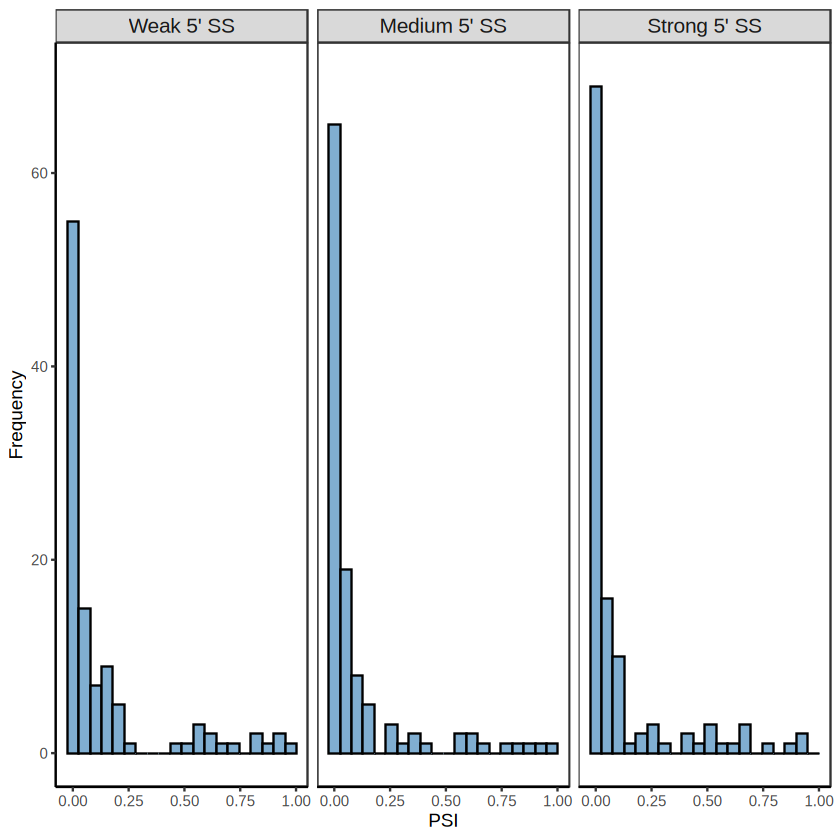

In [ ]:

ggplot(experimental_edit, aes(A375)) + geom_histogram(bins = 20, fill = "#80AED1", color = "black") + facet_wrap(~IDDisplay)+
  theme_bw()+ 
  theme(axis.line = element_line(colour = "black"),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        # panel.border = element_blank(),
        panel.background = element_blank(),
        strip.text = element_text(size = 12)) + 
        xlab("PSI") + 
        ylab("Frequency") +
        ylim(0, 70)
ggsave(file.path(figure_outdir, "figS01_A375_PSI_distribution_by_5SS_strength.pdf"), width = 1200, height = 500, units = "px", dpi = 150)


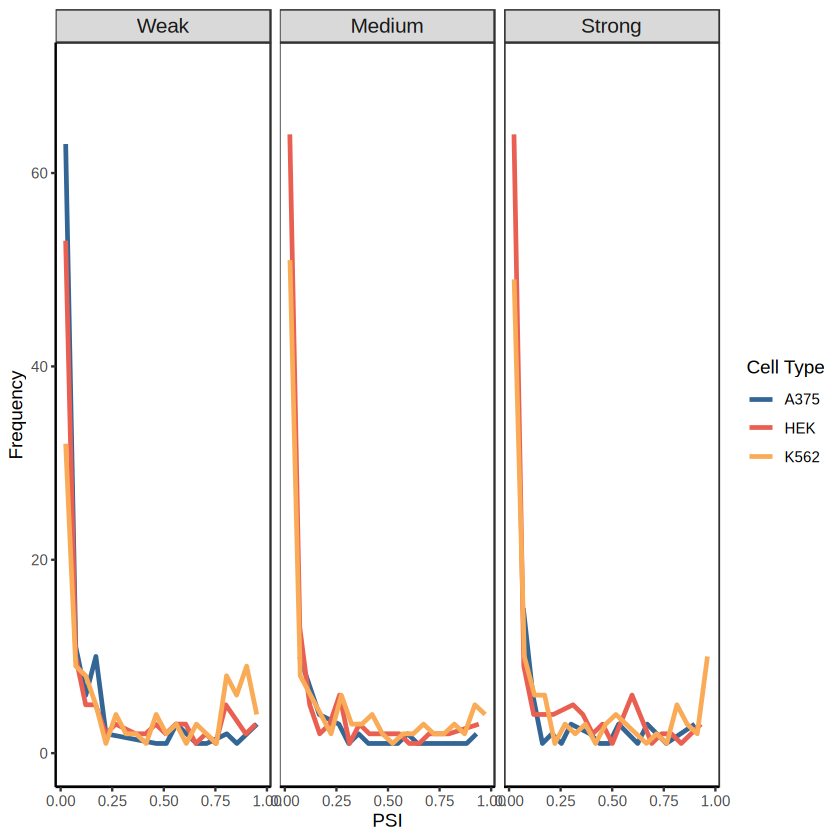

In [ ]:
# ggplot(experimental_edit, aes(A375, K562, color = IDDisplay2)) + geom_point() + 
#   theme_bw()+ 
#   theme(axis.line = element_line(colour = "black"),
#         panel.grid.major = element_blank(),
#         panel.grid.minor = element_blank(),
#         # panel.border = element_blank(),
#         panel.background = element_blank()) + labs(colour = "5' SS Strength")


color_palette2 <- c(
  "#4575B4",  # deep blue
  "#85B6D6",  # slightly lighter/more even blue
  "#E2EFF2",  # less stark pastel blue
  "#FFE3B0",  # warmer, slightly less saturated yellow
  "#EF9651",  # softer orange
  "#D83629"   # red
)

color_palette3 <- c(
"#336695",
"#E96052",
"#F9AB57")


color_palette2_custom <- colorRampPalette(color_palette2)(100)
color_palette2_custom_rev <- colorRampPalette(rev(color_palette2))(100)

# Create manual histogram table with 20 bins for each cell type and splice site strength
experimental_edit_pivot_long <- experimental_edit %>% 
  select(IDDisplay2, GeneID, libraryID, A375, HEK, K562) %>% 
  pivot_longer(cols = c("A375", "HEK", "K562"), names_to = "cellline", values_to = "PSI")

# Calculate frequency for each bin in each cell type and splice site strength combination
histogram_data <- experimental_edit_pivot_long %>%
  filter(!is.na(PSI)) %>%
  group_by(cellline, IDDisplay2) %>%
  mutate(
    bin = cut(PSI, breaks = 20, labels = FALSE),
    bin_center = cut(PSI, breaks = 20, labels = FALSE) * 
      (max(PSI, na.rm = TRUE) - min(PSI, na.rm = TRUE)) / 20 + 
      min(PSI, na.rm = TRUE) - 
      (max(PSI, na.rm = TRUE) - min(PSI, na.rm = TRUE)) / 40
  ) %>%
  group_by(cellline, IDDisplay2, bin, bin_center) %>%
  summarise(frequency = n(), .groups = 'drop') %>%
  arrange(cellline, IDDisplay2, bin)

# Plot the histogram data with one line per cell type and splice site strength
ggplot(histogram_data, aes(x = bin_center, y = frequency, color = cellline)) + 
  geom_line(linewidth = 1) + 
  scale_color_manual(values = color_palette3[1:3]) +
  theme_bw() + 
  facet_wrap(~IDDisplay2) + 
  theme(axis.line = element_line(colour = "black"),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        panel.background = element_blank(),
        strip.text = element_text(size = 12)) + 
  xlab("PSI") + 
  ylab("Frequency") +
  labs(color = "Cell Type", linetype = "5' SS Strength") + 
  ylim(0, 70)

ggsave(file.path(figure_outdir, "figS01_PSI_distribution_by_celltype_and_5SS_lines.pdf"), width = 1200, height = 500, units = "px", dpi = 150)

ggplot(histogram_data, aes(x = bin_center, y = frequency, color = IDDisplay2)) + 
  geom_line(linewidth = 1) + 
  scale_color_manual(values = color_palette3[1:3]) +
  theme_bw() + 
  facet_wrap(~cellline) + 
  theme(axis.line = element_line(colour = "black"),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        panel.background = element_blank(),
        strip.text = element_text(size = 12)) + 
  xlab("PSI") + 
  ylab("Frequency") +
  labs(color = "Cell Type", linetype = "5' SS Strength") + 
  ylim(0, 70)

ggsave(file.path(figure_outdir, "figS01_PSI_distribution_by_5SS_lines.pdf"), width = 1200, height = 500, units = "px", dpi = 150)

# Distribution of all exon lengths.

In [48]:
library(data.table)
library(tidyverse)
figure_outdir <- "/mnt/dawnccle2/melange/figures_outputs/figS01"

SE_filtered <- fread("/mnt/dawnccle2/terra_google_bucket/splicing/ALL_CELLLINE_SE.MATS.JC_withID.txt")

In [49]:
head(SE_filtered)

ID,GeneID,geneSymbol,chr,strand,exonStart_0base,exonEnd,upstreamES,upstreamEE,downstreamES,downstreamEE,IJC_SAMPLE_1,SJC_SAMPLE_1,IncFormLen,SkipFormLen,PValue,FDR,IncLevel1,cellline_name,exonID
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<lgl>,<lgl>,<dbl>,<chr>,<chr>
chrKI270711.1-12800-12964-11706-11758-16870-16922,ENSG00000271254.6,ENSG00000271254,chrKI270711.1,-,12800,12964,11706,11758,16870,16922,98,1,200,100,NA,NA,0.980,22RV1,chrKI270711.1-12800-12964
chrKI270711.1-21056-21159-20006-20221-22932-23113,ENSG00000271254.6,ENSG00000271254,chrKI270711.1,-,21056,21159,20006,20221,22932,23113,82,1,200,100,NA,NA,0.976,22RV1,chrKI270711.1-21056-21159
chrKI270711.1-27336-27439-26290-26505-29278-29488,ENSG00000271254.6,ENSG00000271254,chrKI270711.1,-,27336,27439,26290,26505,29278,29488,53,4,200,100,NA,NA,0.869,22RV1,chrKI270711.1-27336-27439
chrY-57187849-57188028-57184253-57184307-57189425-57189490,ENSG00000124334.17_PAR_Y,IL9R,chrY,+,57187849,57188028,57184253,57184307,57189425,57189490,0,0,200,100,NA,NA,NA,22RV1,chrY-57187849-57188028
chrY-57194042-57194127-57192602-57192708-57196335-57197128,ENSG00000124334.17_PAR_Y,IL9R,chrY,+,57194042,57194127,57192602,57192708,57196335,57197128,0,0,185,100,NA,NA,NA,22RV1,chrY-57194042-57194127
chrY-57082142-57082200-57075977-57076132-57084631-57084769,ENSG00000124333.16_PAR_Y,VAMP7,chrY,+,57082142,57082200,57075977,57076132,57084631,57084769,0,0,158,100,NA,NA,NA,22RV1,chrY-57082142-57082200


In [50]:
all_exons_lengths <- SE_filtered %>% 
    select(exonID, exonStart_0base, exonEnd) %>%
    distinct() %>%
    mutate(exon_length = exonEnd - exonStart_0base)

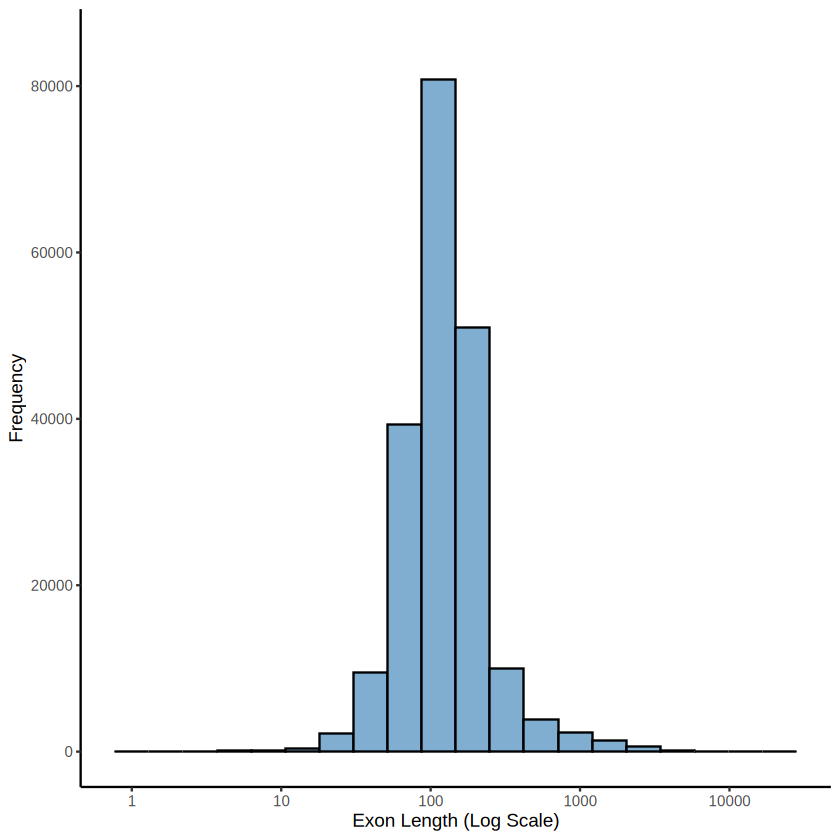

In [51]:
# Plot a histogram of the exon lengths.
ggplot(all_exons_lengths, aes(x = exon_length)) + 
  geom_histogram(bins = 20, fill = "#80AED1", color = "black") +
  scale_x_log10() +
  theme_bw() + 
  theme(axis.line = element_line(colour = "black"),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        panel.background = element_blank(),
        panel.border = element_blank(),
        strip.text = element_text(size = 12)) +
  xlab("Exon Length (Log Scale)") +
  ylab("Frequency") + 
  ylim(0, 85000)
ggsave(file.path(figure_outdir, "figS01_exon_length_distribution.pdf"), width = 600, height = 500, units = "px", dpi = 150)

In [52]:
# Also plot the intron lengths. 
all_introns <- SE_filtered %>% 
select(chr, upstreamEE, downstreamES, exonStart_0base, exonEnd) %>%
distinct() %>% 
mutate(upstream_intron_ID = paste0(chr, ":", upstreamEE, "-", exonStart_0base),
downstream_intron_ID = paste0(chr, ":", exonEnd, "-", downstreamES)) %>%
mutate(upstream_intron_length = exonStart_0base - upstreamEE,
downstream_intron_length = downstreamES - exonEnd) %>%
select(upstream_intron_ID, downstream_intron_ID, upstream_intron_length, downstream_intron_length) %>%
distinct() %>%
pivot_longer(
  cols = c(upstream_intron_length, downstream_intron_length),
  names_to = "intron_type",
  values_to = "intron_length"
) %>%
mutate(intron_id = ifelse(intron_type == "upstream_intron_length", 
                         upstream_intron_ID, 
                         downstream_intron_ID))


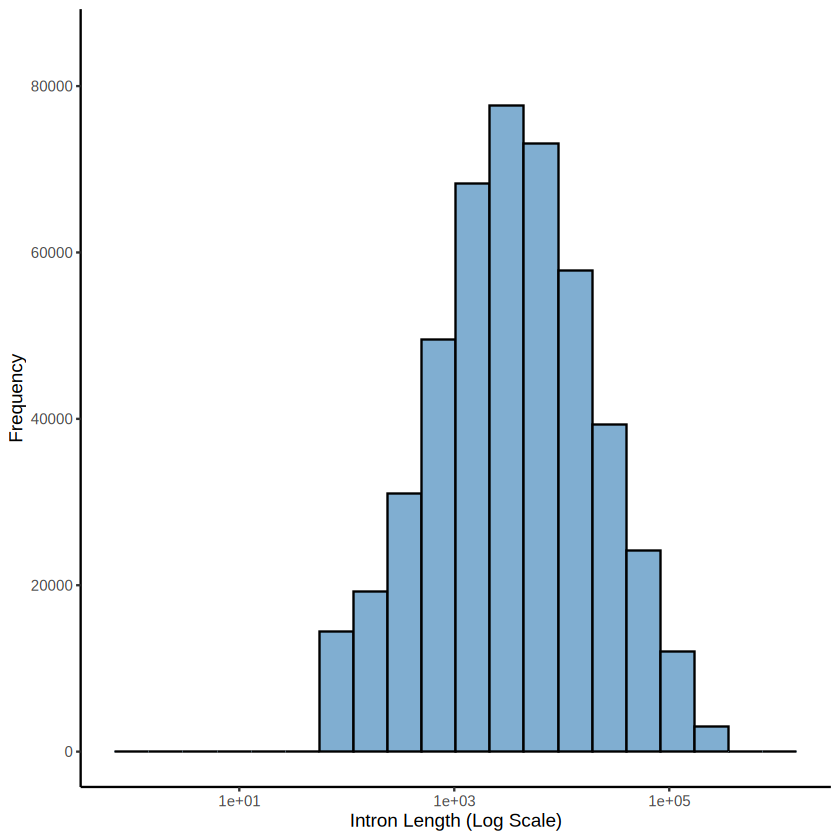

In [53]:
all_introns_unique <- all_introns %>% 
select(intron_id, intron_length) %>%
distinct()

# Plot a histogram of the intron lengths
ggplot(all_introns_unique, aes(x = intron_length)) + 
  geom_histogram(bins = 20, fill = "#80AED1", color = "black") +
  scale_x_log10() +
  theme_bw() + 
  theme(axis.line = element_line(colour = "black"),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        panel.background = element_blank(),
        panel.border = element_blank(),
        strip.text = element_text(size = 12)) +
  xlab("Intron Length (Log Scale)") +
  ylab("Frequency") + 
  ylim(0, 85000)
ggsave(file.path(figure_outdir, "figS01_intron_length_distribution.pdf"), width = 600, height = 500, units = "px", dpi = 150)

# Analyze all CCLE RMATS data

In [1]:
library(data.table)
library(tidyverse)

SE <- fread("/mnt/dawnccle2/data/processed_rmats_output/ALL_CELLLINE_SE.MATS.JC.txt")

# set.seed(100)
# # Sub sample 100,000 rows
# SE_subset_index <- sample(seq(nrow(SE)),200000)
# SE_subset <- SE[SE_subset_index,]
# fwrite(SE_subset, "~/SUBSET_SE.JC.txt")
# 
# # Filter out the rows that have no reads, and total reads < 20. 
SE_filtered <- SE %>% select(-IncLevel2, -IJC_SAMPLE_2, -SJC_SAMPLE_2, -ID.1, -IncLevelDifference) %>%
  filter(!is.na(IncLevel1)) %>%
  filter((IJC_SAMPLE_1 + SJC_SAMPLE_1) > 30)

# Make a unique ID.
# Comment this out because it's too big. 
SE_filtered<- SE_filtered %>%
  mutate(ID = paste(chr, exonStart_0base, exonEnd, upstreamES,upstreamEE, downstreamES, downstreamEE, sep = "-"))
fwrite(SE_filtered, "/mnt/dawnccle2/data/processed_rmats_output/SE_JC_filtered_with_id.txt")

# # Generate the matrix and sort.
SE_matrix <- SE_filtered %>% pivot_wider(names_from = cellline_name, values_from = IncLevel1, id_cols = ID)
fwrite(SE_matrix, "/mnt/dawnccle2/data/processed_rmats_output/SE_JC_matrix.txt")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::last()
✖ lubridate::mday()    masks data.table::mday()
✖ lubridate::minute()  masks data.table::minute()
✖ lubridate::month()   masks data.table::month()
✖ lubridate::quarter() masks data.table::quarter()
✖ lubridate::second()  masks data.table::second()
✖ purrr::transpose()   masks data.table::transpose()
✖ lubridate::wday() 

In [33]:
library(data.table)
library(tidyverse)

# Read in the data.
SE_matrix <- fread("/mnt/dawnccle2/data/processed_rmats_output/SE_JC_matrix.txt")


In [36]:
num_NA_per_row <- SE_matrix %>%
  rowwise() %>%
  mutate(fraction_data = 1 - sum(is.na(c_across(-ID))) / (ncol(SE_matrix) - 1)) %>%
  select(ID, fraction_data)

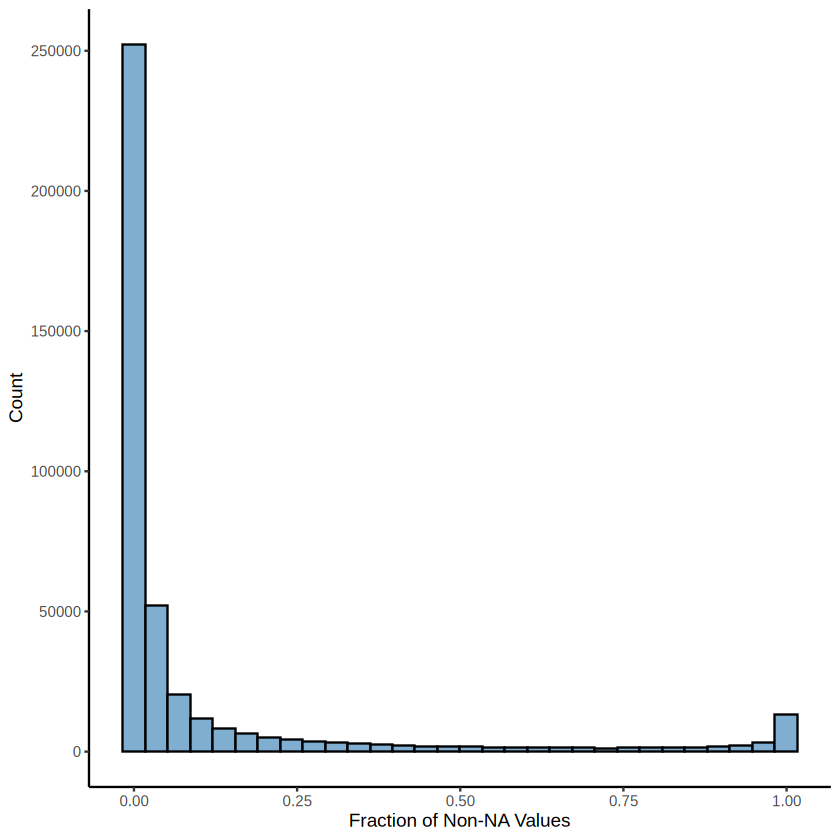

In [42]:
ggplot(num_NA_per_row, aes(x = fraction_data)) +
  geom_histogram(bins = 30, fill = "#80AED1", color = "black") +
  theme_bw() +
  theme(axis.line = element_line(colour = "black"),
        panel.grid.major = element_blank(), 
        panel.grid.minor = element_blank(),
        panel.background = element_blank(),
        panel.border = element_blank(),
        strip.text = element_text(size = 12)) +
  xlab("Fraction of Non-NA Values") +
  ylab("Count")

ggsave(file.path(figure_outdir, "figS01_fraction_non_na_values.pdf"), width = 800, height = 600, units = "px", dpi = 150)


# SpliceAI results on all genomic exons

Rows: 201721 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): ID, donor_prob, acceptor_prob, upstream_intron, skipped_exon, downs...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 1936 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (8): Gene, strand, Tissue1, Tissue2, GeneDescription, chr, start, Event_...
dbl (4): SwitchScore, Tissue1Inc, Tissue2Inc, end

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


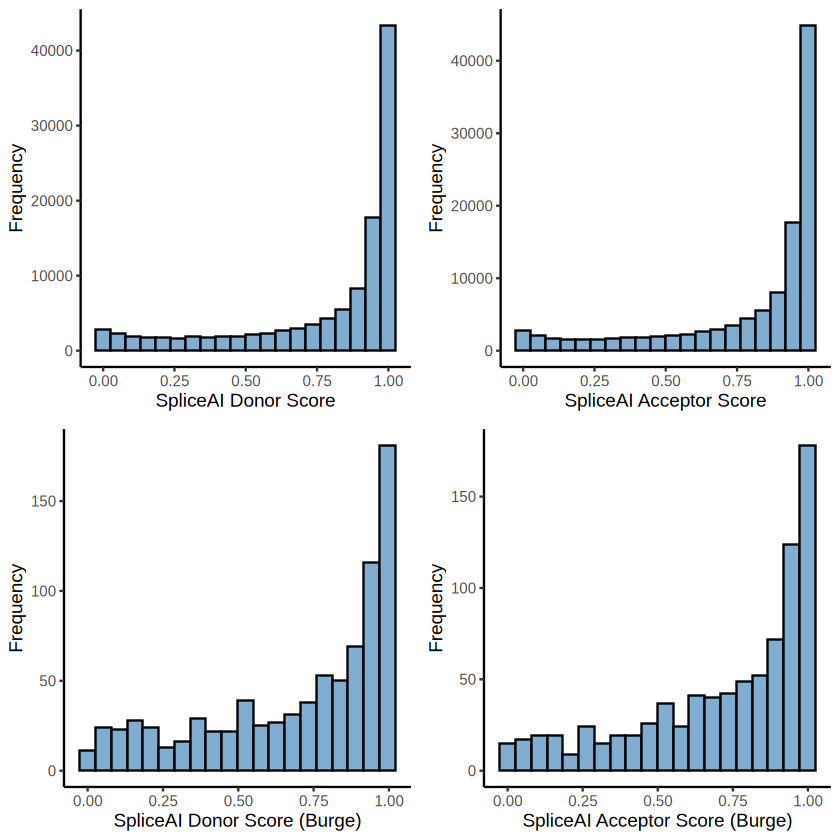

In [11]:
library(data.table)
library(tidyverse)
library(gridExtra)
figure_outdir <- "/mnt/dawnccle2/melange/figures_outputs/figS01"

all_exons_spliceai <- read_csv("/mnt/thechenlab/Dawn/splicing/full_library_unique_exons_only/outputs/MERGED_all_exons_spliceAI_predictions_weak.csv")
all_exons_spliceai <- all_exons_spliceai %>% filter(donor_prob != "None") %>% 
  mutate(donor_prob = as.numeric(donor_prob)) %>% 
  mutate(acceptor_prob = as.numeric(acceptor_prob)) %>% 
  separate(ID, into = c("GeneID", "GeneName", "ID"), sep = ";") %>% 
  mutate(exonID = str_extract(ID, "^([^-]*-[^-]*-[^-]*)")) %>%
  arrange(exonID)

burge <- read_tsv("/mnt/dawnccle2/melange/data/burge_2007_exon_skipping_Supp_cleaned_with_hg38coord.tsv")
burge_with_ID <- burge %>% mutate(exonID = paste(chr, start, end, sep = "-")) %>% arrange(exonID)
burge_with_spliceai <- all_exons_spliceai %>% filter(exonID %in% burge_with_ID$exonID)

s1 <- ggplot(all_exons_spliceai, aes(x = donor_prob)) + 
  geom_histogram(bins = 20, fill = "#80AED1", color = "black") +
  theme_bw() + 
  theme(axis.line = element_line(colour = "black"),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        panel.background = element_blank(),
        panel.border = element_blank(),
        strip.text = element_text(size = 12)) +
  xlab("SpliceAI Donor Score") +
  ylab("Frequency")

s2 <- ggplot(all_exons_spliceai, aes(x = acceptor_prob)) + 
  geom_histogram(bins = 20, fill = "#80AED1", color = "black") +
  theme_bw() + 
  theme(axis.line = element_line(colour = "black"),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        panel.background = element_blank(),
        panel.border = element_blank(),
        strip.text = element_text(size = 12)) +
  xlab("SpliceAI Acceptor Score") +
  ylab("Frequency")

s5 <- ggplot(burge_with_spliceai, aes(x = donor_prob)) + 
  geom_histogram(bins = 20, fill = "#80AED1", color = "black") +
  theme_bw() + 
  theme(axis.line = element_line(colour = "black"),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        panel.background = element_blank(),
        panel.border = element_blank(),
        strip.text = element_text(size = 12)) +
  xlab("SpliceAI Donor Score (Burge)") +
  ylab("Frequency")

s6 <- ggplot(burge_with_spliceai, aes(x = acceptor_prob)) + 
  geom_histogram(bins = 20, fill = "#80AED1", color = "black") +
  theme_bw() + 
  theme(axis.line = element_line(colour = "black"),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        panel.background = element_blank(),
        panel.border = element_blank(),
        strip.text = element_text(size = 12)) +
  xlab("SpliceAI Acceptor Score (Burge)") +
  ylab("Frequency")

p <- grid.arrange(s1, s2, s5, s6, ncol = 2)
ggsave(file.path(figure_outdir, "figS01_spliceai_score_distributions.pdf"), plot = p, width = 1200, height = 1200, units = "px", dpi = 150)


# Look at SpliceAI correlation with pilot data

Rows: 4068 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): id, upstream_exon, downstream_exon, libraryID
dbl (6): donor_prob, acceptor_prob, 293, A375, HEK, K562

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`summarise()` has grouped output by 'id', 'upstream_exon', 'downstream_exon'.
You can override using the `.groups` argument.
`summarise()` has grouped output by 'celltype', 'context'. You can override
using the `.groups` argument.
`summarise()` has grouped output by 'celltype', 'context'. You can override
using the `.groups` argument.


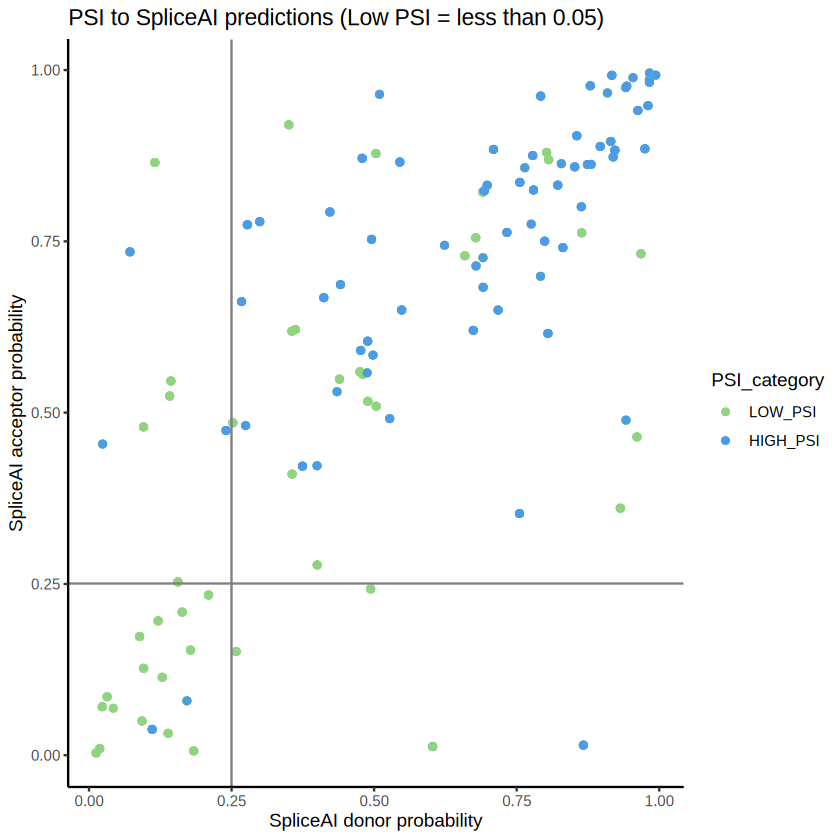

In [31]:
spliceai_PSI <- read_csv("/mnt/dawnccle2/melange/data/twist_pilot_spliceai_prediction_with_PSI.csv")

spliceai_grouped_by_element <- spliceai_PSI %>% 
  pivot_longer(cols = any_of(c("293", "A375", "HEK", "K562")), names_to = "celltype", values_to = "PSI") %>% 
  group_by(id, upstream_exon, downstream_exon, celltype) %>% 
  summarise(PSI_mean = mean(PSI, na.rm = T), PSI_sd = sd(PSI, na.rm = T), donor_prob = donor_prob[1], acceptor_prob = acceptor_prob[1]) %>% 
  mutate(PSI_category = ifelse(PSI_mean > 0.05, "HIGH_PSI", "LOW_PSI")) %>% 
  mutate(PSI_category = factor(PSI_category, levels = c("LOW_PSI", "HIGH_PSI"))) %>% 
  mutate(context = paste(upstream_exon, downstream_exon, sep = "-")) %>% 
  mutate(donor_prob_category = ifelse(donor_prob < 0.25, "SD_LOW", "SD_HIGH")) %>% 
  mutate(acceptor_prob_category = ifelse(acceptor_prob < 0.25, "SA_LOW", "SA_HIGH")) %>% 
  mutate(overall_prob_category = ifelse(acceptor_prob < 0.25 & donor_prob <0.25, "CAT_LOW", "CAT_HIGH")) %>% 
  mutate(overall_prob_category = factor(overall_prob_category, levels = c("CAT_LOW", "CAT_HIGH"))) %>% 
  arrange(id, context)
  

colors <- c("#90D380", "#4B9CE4")

# look at spliceAI prediction by element
ggplot(spliceai_grouped_by_element %>% filter(!is.na(PSI_mean) & downstream_exon == "actn1" & upstream_exon == "weak_upstream_short"), aes(donor_prob, acceptor_prob, color = PSI_category)) + 
  geom_point() + 
  theme_bw() +
  theme(axis.line = element_line(colour = "black"),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(), 
        panel.background = element_blank(),
        panel.border = element_blank(),
        strip.text = element_text(size = 12)) +
  geom_vline(xintercept = 0.25, color = "gray50") + 
  geom_hline(yintercept = 0.25, color = "gray50") + 
  xlab("SpliceAI donor probability") +
  ylab("SpliceAI acceptor probability") +
  ggtitle("PSI to SpliceAI predictions (Low PSI = less than 0.05)") +
  scale_color_manual(values = colors)
ggsave(file.path(figure_outdir, "figS01_spliceai_prediction_by_element.pdf"), width = 800, height = 600, units = "px", dpi = 150)

################ Decision Boundary ###############
# Look at how good the manual cut off is:
by_PSI_category <- spliceai_grouped_by_element %>% 
  filter(!is.na(PSI_category)) %>% 
  group_by(celltype, context, PSI_category) %>% 
  summarise(in_low_bucket = mean(overall_prob_category == "CAT_LOW"),
            in_high_bucket = mean(overall_prob_category == "CAT_HIGH") , n_elements = n())

by_prediction_category <- spliceai_grouped_by_element %>% 
  filter(!is.na(PSI_category)) %>% 
  group_by(celltype, context, overall_prob_category) %>% 
  summarise(in_low_bucket = mean(PSI_category == "LOW_PSI"),
            in_high_bucket = mean(PSI_category == "HIGH_PSI") , n_elements = n())


# ggplot(by_PSI_category, aes(context, in_low_bucket,fill = PSI_category)) + 
#   geom_bar(stat = "identity", position = "dodge") + 
#   theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

# ggplot(by_prediction_category, aes(context, in_low_bucket, fill = overall_prob_category)) + 
#   geom_bar(stat = "identity", position = "dodge") + 
#   theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1)) +
#   ylab("% with observed low PSI")



`summarise()` has grouped output by 'celltype', 'context',
'overall_prob_category'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'context'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'celltype', 'context', 'lm_pred_category'.
You can override using the `.groups` argument.
`summarise()` has grouped output by 'celltype', 'context', 'lm_pred_category'.
You can override using the `.groups` argument.
`summarise()` has grouped output by 'celltype', 'context', 'lm_pred_category'.
You can override using the `.groups` argument.
`summarise()` has grouped output by 'celltype', 'context', 'lm_pred_category'.
You can override using the `.groups` argument.
`summarise()` has grouped output by 'celltype', 'context', 'lm_pred_category'.
You can override using the `.groups` argument.
`summarise()` has grouped output by 'celltype', 'context', 'lm_pred_category'.
You can override using the `.groups` argument.
`summarise()` has g

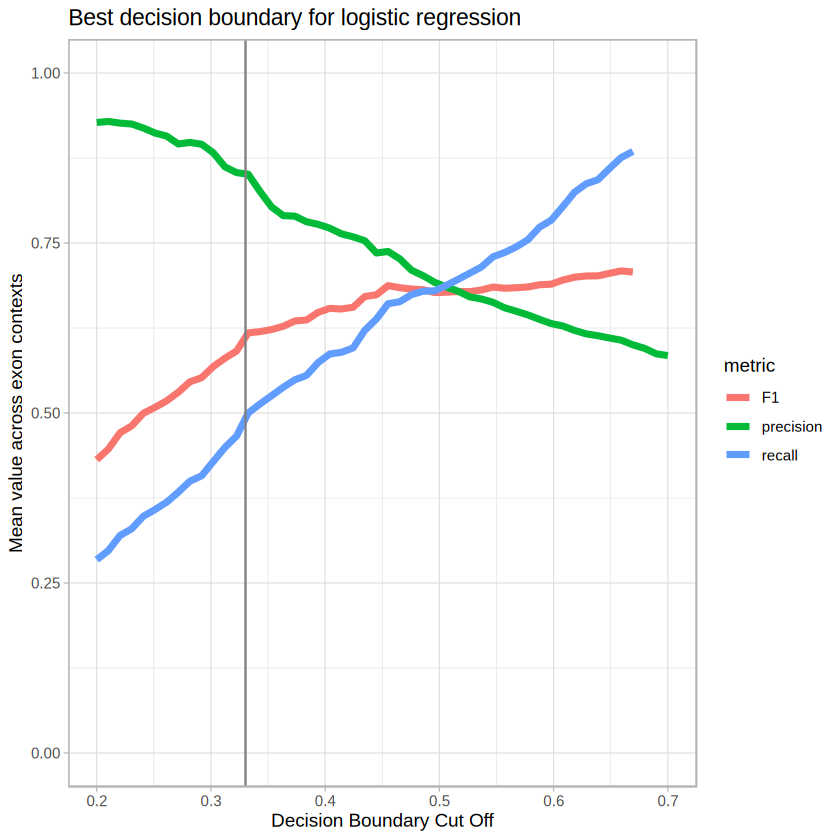

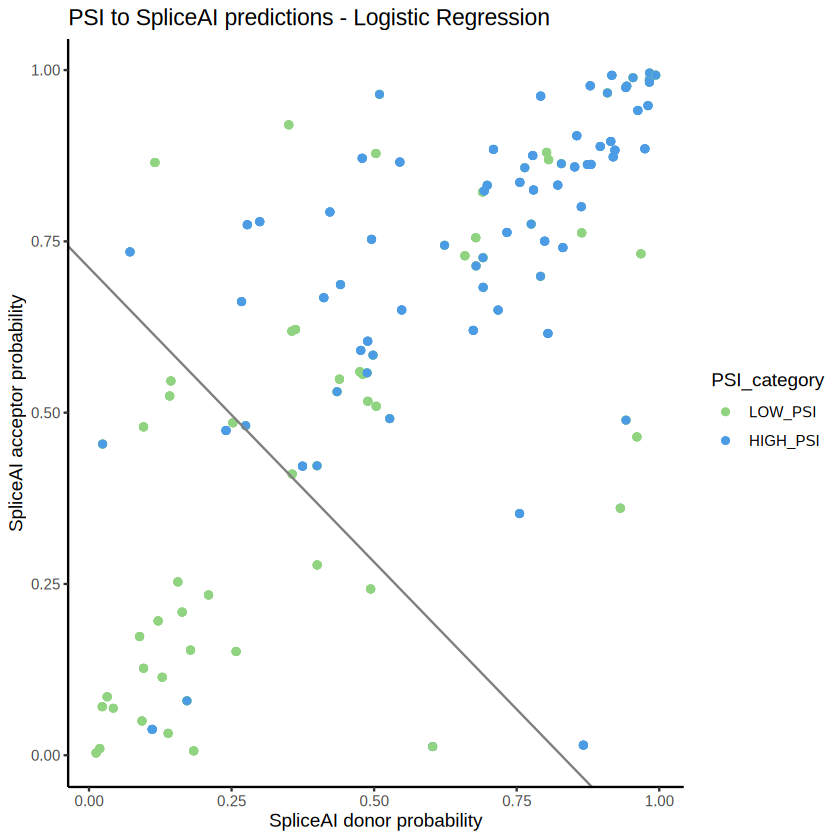

In [32]:
# Okay let's look at precision and recall for just using a 25% PSI cutoff. 
confusion_matrix <- spliceai_grouped_by_element %>% 
  filter(!is.na(PSI_category)) %>% 
  group_by(celltype, context, overall_prob_category, PSI_category) %>% 
  summarise(n= n()) %>% pivot_wider(names_from = c(overall_prob_category, PSI_category), values_from = n) %>% 
  # Precision is TP / (TP+FP)
  mutate(precision = CAT_LOW_LOW_PSI/(CAT_LOW_LOW_PSI + CAT_LOW_HIGH_PSI)) %>% 
  # Recall is TP / (TP+FN) 
  mutate(recall = CAT_LOW_LOW_PSI/(CAT_LOW_LOW_PSI + CAT_HIGH_LOW_PSI)) %>% 
  # F1 metric is 2*(precision * recall)/(precision + recall)
  mutate(F1 = 2*(precision * recall)/(precision + recall)) %>% 
  select(-CAT_LOW_LOW_PSI, -CAT_LOW_HIGH_PSI, -CAT_HIGH_LOW_PSI, -CAT_HIGH_HIGH_PSI) %>% 
  pivot_longer(cols = any_of(c("precision", "recall")), names_to = "metric", values_to = "value")


confusion_with_error_bars <- confusion_matrix %>% group_by(context, metric) %>%
  summarise(value_mean = mean(value), sd = sd(value))

p1 <- ggplot(confusion_with_error_bars, aes(context, value_mean, fill = metric)) +
  geom_bar(stat = "identity", position = "dodge") +
  theme_light() + 
  geom_errorbar(position=position_dodge(width=0.9), 
                aes(x=context, ymin=value_mean-sd, ymax=value_mean+sd), color = "gray50", 
                width=0.3, alpha=0.9, size=0.8) + 
  # scale_fill_brewer(palette = 10) + 
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1)) +
  ggtitle("Precision and recall by using SpliceAI probability < 0.25 cutoff")

# Precision and recall for logistic regression.
# try a logistic regression.
# EDIT: Decision boundary looks terrible. I prefer a conservative estimate.
mdl <- glm(PSI_category~donor_prob+acceptor_prob , data = spliceai_grouped_by_element%>% 
             filter(!is.na(PSI_mean) & downstream_exon == "actn1"), family=binomial)
slope <- coef(mdl)[2]/(-coef(mdl)[3])
intercept <- coef(mdl)[1]/(-coef(mdl)[3])

saveRDS(mdl, "/mnt/dawnccle2/melange/data/logistic_model.rds")

get_logistic_regression_slope<- function(mdl, odds_cutoff = 0.5){
  return ( coef(mdl)[2]/(-coef(mdl)[3]))
}

get_logistic_regression_intercept <- function(mdl, odds_cutoff = 0.5){
  value <- log((1-odds_cutoff)/odds_cutoff)/(-coef(mdl)[3]) - coef(mdl)[1]/coef(mdl)[3]
  return(value)
}

# Add the prediction.
spliceai_grouped_by_element$lm_prediction <- mdl %>% predict(spliceai_grouped_by_element, type = "response")
# Try to find the best decision boundary. 
db_range <- base::seq(0.2,0.7, length = 50)
output_metrics <- data.frame()
for (db in db_range){
  spliceai_grouped_by_element <- spliceai_grouped_by_element %>% 
    mutate(lm_pred_category = ifelse(lm_prediction>db, "CAT_HIGH", "CAT_LOW"))
  
  confusion_matrix <- spliceai_grouped_by_element %>% 
    filter(!is.na(PSI_category)) %>% 
    filter(!(downstream_exon %in% c("bglobin", "libonly", "smn1"))) %>% 
    group_by(celltype, context, lm_pred_category, PSI_category) %>% 
    summarise(n= n()) %>% pivot_wider(names_from = c(lm_pred_category, PSI_category), values_from = n) %>% 
    # Precision is TP / (TP+FP)
    mutate(precision = CAT_LOW_LOW_PSI/(CAT_LOW_LOW_PSI + CAT_LOW_HIGH_PSI)) %>% 
    # Recall is TP / (TP+FN) 
    mutate(recall = CAT_LOW_LOW_PSI/(CAT_LOW_LOW_PSI + CAT_HIGH_LOW_PSI)) %>% 
    # F1 metric is 2*(precision * recall)/(precision + recall)
    mutate(F1 = 2*(precision * recall)/(precision + recall)) %>% 
    select(-CAT_LOW_LOW_PSI, -CAT_LOW_HIGH_PSI, -CAT_HIGH_LOW_PSI, -CAT_HIGH_HIGH_PSI) %>% 
    pivot_longer(cols = any_of(c("precision", "recall", "F1")), names_to = "metric", values_to = "value") %>% 
    mutate(boundary = db)
  output_metrics <- rbind(output_metrics, confusion_matrix)
}

confusion_with_error_bars <- output_metrics %>% group_by(boundary, metric) %>%
  summarise(value_mean = mean(value), sd = sd(value))

# Plot the decision boundary.
ggplot(confusion_with_error_bars, aes(boundary, value_mean, color = metric, group = metric)) + 
  geom_line(size = 1.5) + ylim(0,1) + 
  geom_vline(xintercept = 0.33, color = "gray50") + theme_light() + 
  xlab("Decision Boundary Cut Off") + 
  ylab("Mean value across exon contexts") + 
  ggtitle("Best decision boundary for logistic regression")


# ggplot(confusion_with_error_bars, aes(context, value_mean, fill = metric)) +
#   geom_bar(stat = "identity", position = "dodge") +
#   theme_light() + 
#   geom_errorbar(position=position_dodge(width=0.9), 
#                 aes(x=context, ymin=value_mean-sd, ymax=value_mean+sd), color = "gray50", 
#                 width=0.3, alpha=0.9, size=0.8) + 
#   theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1)) + 
#   ggtitle("Precision and recall for logistic regression model") 

slope <- get_logistic_regression_slope(mdl)
intercept <- get_logistic_regression_intercept(mdl, odds_cutoff = 0.33)

ggplot(spliceai_grouped_by_element %>% filter(!is.na(PSI_mean) & downstream_exon == "actn1" & upstream_exon == "weak_upstream_short"), aes(donor_prob, acceptor_prob, color = PSI_category)) + 
  geom_point() + 
  theme_bw() +
  theme(axis.line = element_line(colour = "black"),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(), 
        panel.background = element_blank(),
        panel.border = element_blank(),
        strip.text = element_text(size = 12)) +
  geom_abline(slope=slope, intercept = intercept, color = "gray50") +
  xlab("SpliceAI donor probability") +
  ylab("SpliceAI acceptor probability") +
  ggtitle("PSI to SpliceAI predictions - Logistic Regression") +
  scale_color_manual(values = colors)
ggsave(file.path(figure_outdir, "figS01_spliceai_prediction_by_element_logistic.pdf"), width = 800, height = 600, units = "px", dpi = 150)

# p2 <- ggplot(confusion_with_error_bars, aes(context, value_mean, fill = metric)) +
#   geom_bar(stat = "identity", position = "dodge") +
#   theme_light() + 
#   geom_errorbar(position=position_dodge(width=0.9), 
#                 aes(x=context, ymin=value_mean-sd, ymax=value_mean+sd), color = "gray50", 
#                 width=0.3, alpha=0.9, size=0.8) + 
#   theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1)) + 
#   ggtitle("Precision and recall for logistic regression model")

# grid.arrange(p1, p2, nrow = 1)

# # Look at the weak only. 
# spliceai_PSI_weak <- spliceai_PSI %>% 
#   filter(downstream_exon == "actn1") %>% 
#   pivot_longer(cols = any_of(c("293", "A375", "HEK", "K562")), names_to = "celltype", values_to = "PSI") %>% 
#   mutate(donor_prob_category = ifelse(donor_prob < 0.25, "SD_LOW", "SD_HIGH")) %>% 
#   mutate(acceptor_prob_category = ifelse(acceptor_prob < 0.25, "SA_LOW", "SA_HIGH")) 
# spliceai_PSI_weak %>% group_by(donor_prob_category, acceptor_prob_category,celltype) %>% 
#   summarise(mean_PSI = mean(PSI, na.rm = T), n_elements = n(), perc = n()/length(unique(spliceai_PSI$id)))

# ggplot(spliceai_PSI_weak, aes(donor_prob, acceptor_prob, color = PSI)) + geom_point() + facet_grid(donor_prob_category + acceptor_prob_category~celltype) + theme_light()